<a href="https://colab.research.google.com/github/eshghinezhad/ML/blob/master/Probabilistic%20Models%5C10_Probabilistic_models_v2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilistic Models

The following code creates the Bayes Net structure depicted in Figure 13.2 of Russell Norvig (4e).

![Figure 13.2](BayesNet.png)


## Defining a model in pgmpy
The platform we will use later is a good one, but it is not particularly transparent.  For comparison, we illustrate creation of a model in pgmpy, which is a bit more human-friendly.

In [ ]:
!pip install pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Step 1: Define the network structure.
alarm_model = DiscreteBayesianNetwork(
    [
        ("Burglary", "Alarm"),
        ("Earthquake", "Alarm"),
        ("Alarm", "JohnCalls"),
        ("Alarm", "MaryCalls"),
    ]
)

# Step 2: Define the CPDs.
cpd_burglary = TabularCPD(variable="Burglary", variable_card=2, values=[[0.999], [0.001]])
cpd_earthquake = TabularCPD(variable="Earthquake", variable_card=2, values=[[0.998], [0.002]])

cpd_alarm = TabularCPD(
    variable="Alarm",
    variable_card=2,
    values=[[0.999, 0.71, 0.06, 0.05],   # P(Alarm=F | B, E)
            [0.001, 0.29, 0.94, 0.95]],  # P(Alarm=T | B, E)
    evidence=["Burglary", "Earthquake"],
    evidence_card=[2, 2],
)
cpd_johncalls = TabularCPD(
    variable="JohnCalls",
    variable_card=2,
    values=[[0.95, 0.10],   # P(John=F | Alarm=F), P(John=F | Alarm=T)
            [0.05, 0.90]],  # P(John=T | Alarm=F), P(John=T | Alarm=T)
    evidence=["Alarm"],
    evidence_card=[2],
)
cpd_marycalls = TabularCPD(
    variable="MaryCalls",
    variable_card=2,
    values=[[0.99, 0.30],   # P(Mary=F | Alarm=F), P(Mary=F | Alarm=T)
            [0.01, 0.70]],  # P(Mary=T | Alarm=F), P(Mary=T | Alarm=T)
    evidence=["Alarm"],
    evidence_card=[2],
)

# Step 3: Add the CPDs to the model.
alarm_model.add_cpds(cpd_burglary, cpd_earthquake, cpd_alarm, cpd_johncalls, cpd_marycalls)

# Step 4: Check if the model is correctly defined.
alarm_model.check_model()

True

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


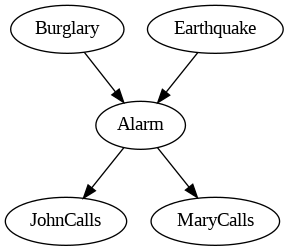

In [ ]:
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

#  Reid note: changing "neato" ---> "dot" will give a nicer layout
from IPython.display import Image
viz = alarm_model.to_graphviz()
#viz.draw('alarm.png', prog='neato')
viz.draw('alarm.png', prog='dot')
Image('alarm.png')

## Defining a model in Pomegranate
Pomegranate is a popular package for this type of work.  Recent versions are built on top of PyTorch for speed.  However, this means that networks are built using tensors of numbers only, which is a little less obvious.

In [ ]:
!pip install pomegranate
from pomegranate.distributions import Categorical
from pomegranate.distributions import ConditionalCategorical
from pomegranate.bayesian_network import BayesianNetwork


#Note that recent versions of Pomegranate do not support text labels for states; they are only identified by integer.

#To correspond to the normal convention that 0 is false and 1 is true, the order of the states/probabilties is reversed
#from the text.  (In the text, t is listed first, but here, false(0) is first.)

burglary = Categorical([
    [0.999, 0.001]
])
earthquake = Categorical([
    [0.998, 0.002]
])

alarm = ConditionalCategorical([
        [
            [ #Burglary - First value (f)
                [0.99, 0.01], #Earthquake - First value (f)
                [0.3, 0.7], #Earthquake - Second value (t)

            ],
            [ #Burglary - Second value (t)
                [0.99, 0.01], #Earthquake - First value (f)
                [0.3, 0.7], #Earthquake - Second value (t)
            ],
        ]
    ])

johncalls = ConditionalCategorical([
    [
        [0.95, 0.05], #Alarm - First value (f)
        [0.1, 0.9], #Alarm - Second value (t)
    ],
])

marycalls = ConditionalCategorical([
    [
        [0.99, 0.01], #Alarm - First value (f)
        [0.3, 0.7], #Alarm - Second value (t)
    ],
])

model = BayesianNetwork()
model.add_distributions([burglary, earthquake, alarm, johncalls, marycalls])
model.add_edge(burglary, alarm)
model.add_edge(earthquake, alarm)
model.add_edge(alarm, johncalls)
model.add_edge(alarm, marycalls)

print(model)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.2 MB/s eta 0:00:00
  Created wheel for apricot-select: filename=apricot_select-0.6.1-py3-none-any.whl size=48767 sha256=43edd0fe1e049e0b6f698e4d44065537eac393f26a713a85406c04c056c602cc
  Stored in directory: /root/.cache/pip/wheels/19/ce/18/f10e7debb348bf14d4ab90c8b657a91a79f1106b699a1121c3
Successfully built apricot-select
BayesianNetwork(
  (distributions): ModuleList(
    (0-1): 2 x Categorical()
    (2): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2x2])
      (_w_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_xw_sum): [tensor([[[0., 0.],
               [0., 0.]],
      
              [[0., 0.],
               [0., 0.]]])]
      (_log_probs): [tensor([[[-0.0101, -4.6052],
               [-1.2040, -0.3567]],
      
              [[-

## Joint distribution

In [ ]:
# Calcuating the joint probability for a particular outcome.  (Note that 0 represents 'f', so this is the case where all
# are false.

# Note that variables are listed in the order they were added to the model, so [burglary, earthquake, alarm, johncalls, marycalls].
print(model.probability([
    [0, 1, 1, 1, 0]
]))


tensor([0.0004])


In [ ]:
#Enumerating all possible out outcomes for the network
values = [0,1]
enumerated = [[b, e, a, j, m] for b in values for e in values for a in values for j in values for m in values]


print(list(enumerated))

[[0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 0, 1, 0], [0, 0, 0, 1, 1], [0, 0, 1, 0, 0], [0, 0, 1, 0, 1], [0, 0, 1, 1, 0], [0, 0, 1, 1, 1], [0, 1, 0, 0, 0], [0, 1, 0, 0, 1], [0, 1, 0, 1, 0], [0, 1, 0, 1, 1], [0, 1, 1, 0, 0], [0, 1, 1, 0, 1], [0, 1, 1, 1, 0], [0, 1, 1, 1, 1], [1, 0, 0, 0, 0], [1, 0, 0, 0, 1], [1, 0, 0, 1, 0], [1, 0, 0, 1, 1], [1, 0, 1, 0, 0], [1, 0, 1, 0, 1], [1, 0, 1, 1, 0], [1, 0, 1, 1, 1], [1, 1, 0, 0, 0], [1, 1, 0, 0, 1], [1, 1, 0, 1, 0], [1, 1, 0, 1, 1], [1, 1, 1, 0, 0], [1, 1, 1, 0, 1], [1, 1, 1, 1, 0], [1, 1, 1, 1, 1]]


In [ ]:
print(model.probability(enumerated))

#Note that the probabilities for the complete joint probability distribution sum to 1.
print(sum(model.probability(enumerated)))

tensor([9.2830e-01, 9.3768e-03, 4.8858e-02, 4.9352e-04, 2.9910e-04, 6.9790e-04,
        2.6919e-03, 6.2811e-03, 5.6374e-04, 5.6943e-06, 2.9670e-05, 2.9970e-07,
        4.1958e-05, 9.7902e-05, 3.7762e-04, 8.8112e-04, 9.2923e-04, 9.3862e-06,
        4.8907e-05, 4.9401e-07, 2.9940e-07, 6.9860e-07, 2.6946e-06, 6.2874e-06,
        5.6430e-07, 5.7000e-09, 2.9700e-08, 3.0000e-10, 4.2000e-08, 9.8000e-08,
        3.7800e-07, 8.8200e-07])
tensor(1.0000)


In [ ]:
model.probability([
    [0, 1, 1, 1, 0] ])

tensor([0.0004])

## Prediction

One of the strengths of this approach is that we can set the values of any observed variables, and calculate the probabilty of any unobserved variables. We are not limited to a pre-defined target variable; any of the variables can be predicted, or used as evidence.

In [ ]:
import torch

#If alarm is true, what is the probability that mary calls? (All of the other unobserved variables will also be calculated.)

#To make predictions in Pomegranate, we need to provide a tensor with the evidence, as well as a mask that shows
#which variables are observed (True) and unobserved (False).  In the evidence, obviously the observed variable(s) should
#have the observed value(s).  The values of the unobserved values are ignored, so they are inconsequential.  Using a special
#value like -1 can help to identify unobserved values.

evidence = torch.tensor([[-1, -1, 1, -1, -1]])
pred_mask = torch.tensor([[False, False, True, False, False]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


/tmp/ipykernel_39059/1360378869.py:13: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


In [ ]:
# Note that with alarm set to 1 (t), JohnCalls and MaryCalls are conditionally independent of all other nodes.  The
# probabilities should match those in the network definition.

# The probabilities of burglary and earthquake are updated based on the evidence that alarm is true.  Note that
# even with alarm true, the probabilities for each of these events are very low.  This is because the prior for
# two events is so low--there is a much higher likelihood of false positives, simply because the probability of
# 'false' is so high.
print(model.predict(masked))
print(model.predict_proba(masked))


tensor([[0, 0, 1, 1, 1]])
[tensor([[0.9990, 0.0010]]), tensor([[0.8770, 0.1230]]), tensor([[0., 1.]]), tensor([[0.1000, 0.9000]]), tensor([[0.3000, 0.7000]])]


In [ ]:
#Given that independence, if alarm is true, setting johncalls shouldn't impact the probability that marycalls.
evidence = torch.tensor([[-1, -1, 1, 1, -1]])
pred_mask = torch.tensor([[False, False, True, True, False]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)
model.predict_proba(masked)

/tmp/ipykernel_5530/3192863869.py:5: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


[tensor([[0.9990, 0.0010]]),
 tensor([[0.8770, 0.1230]]),
 tensor([[0., 1.]]),
 tensor([[0., 1.]]),
 tensor([[0.3000, 0.7000]])]

In [ ]:
evidence = torch.tensor([[1, 1, -1, -1, -1]])
pred_mask = torch.tensor([[False, False, True, True, False]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)
model.predict_proba(masked)

NameError: name 'torch' is not defined

In [ ]:
#But if alarm is not observed, marycalls is not independent from johncalls.
evidence = torch.tensor([[-1, -1, -1, 1, -1]])
pred_mask = torch.tensor([[False, False, False, True, False]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)
model.predict_proba(masked)

/tmp/ipykernel_5530/409985925.py:5: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


[tensor([[0.9990, 0.0010]]),
 tensor([[0.9784, 0.0216]]),
 tensor([[0.8284, 0.1716]]),
 tensor([[0., 1.]]),
 tensor([[0.8716, 0.1284]])]

In [ ]:
#If there is an earthquake, what are the probabilities that johncalls and marycalls?
evidence = torch.tensor([[1, 1, -1, -1, -1]])
pred_mask = torch.tensor([[True, True, False, False, False]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)
model.predict_proba(masked)

/tmp/ipykernel_5530/367113912.py:5: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


[tensor([[0., 1.]]),
 tensor([[0., 1.]]),
 tensor([[0.3000, 0.7000]]),
 tensor([[0.3550, 0.6450]]),
 tensor([[0.5070, 0.4930]])]

In [ ]:
#If both johncalls and marycalls, what is the probability of a burglary and of an earthquake?
evidence = torch.tensor([[-1, -1, -1, 1, 1]])
pred_mask = torch.tensor([[False, False, False, True, True]])

masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)
model.predict_proba(masked)

/tmp/ipykernel_5530/3541109056.py:5: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  masked = torch.masked.MaskedTensor(evidence, mask=pred_mask)


[tensor([[0.9990, 0.0010]]),
 tensor([[0.8849, 0.1151]]),
 tensor([[0.0645, 0.9355]]),
 tensor([[0., 1.]]),
 tensor([[0., 1.]])]

## Sampling

Here, we illustrate both sampling from the complete distribution, as well as rejection sampling to perform approximate inference.


In [ ]:
#Drawing samples from the network
model.sample(10).type(torch.float32)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [ ]:
#Computing the average for each variable (i.e., frequency of '1'), over a large number of samples
model.sample(100000).type(torch.float32).mean(dim=0)

tensor([0.0010, 0.0020, 0.0111, 0.0595, 0.0174])

In [ ]:
#Recall that sampling methods are often used for approximate inference.  (It might not be necessary for this
#small network, but it exact inference is problematic as networks get larger.)


#Using rejection sampling approximate the probability for each variable when johncalls is true

numsamples = 100000
samples = model.sample(numsamples).type(torch.float32)

filtered_samples = samples[samples[:,3] == 1]

print(filtered_samples)

#Note that only a small proportion of the generated samples match the evidence
print(filtered_samples.shape)


tensor([[0., 0., 1., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 1., 0.],
        ...,
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.]])
torch.Size([5993, 5])


In [ ]:
#Note the close correspondence between these results, and those from inference above for the same evidence.
print(filtered_samples.mean(dim=0))

tensor([8.3431e-04, 2.4362e-02, 1.7253e-01, 1.0000e+00, 1.3399e-01])


## Fitting network to the data
Above, we built the network using predetermined probabilities.  However, it is possible to define the structure of the network, and then determine the probabilities by fitting the network to data.  In Pomogranate, EM is used to find the conditional probabilities.

We will use our existing network structure, and fit it to a set of data.  We will start by generating a simple synthetic dataset, essentially sampling in topological order.

In [ ]:
import random
rand = random.Random()

def draw_sample():
    b = 1 if rand.random()< 0.05 else 0
    e = 1 if rand.random()< 0.015 else 0

    if b==1 or e==1:
        p_a = .9
    else:
        p_a = .07
    a = 1 if rand.random()< p_a else 0

    p_j = .85 if a==1 else .03
    j = 1 if rand.random()< p_j else 0

    p_m = .75 if a==1 else .07
    m = 1 if rand.random()< p_m else 0

    return [b, e, a, j, m]

def draw_samples(n):
    l = []
    for i in range(n):
        l.append(draw_sample())
    return l

print(draw_samples(10))



[[0, 0, 1, 1, 1], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [1, 0, 1, 1, 0]]


In [ ]:
samples = draw_samples(100000)

In [ ]:
model.fit(samples)

BayesianNetwork(
  (distributions): ModuleList(
    (0-1): 2 x Categorical()
    (2): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2x2])
      (_w_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_xw_sum): [tensor([[[0., 0.],
               [0., 0.]],
      
              [[0., 0.],
               [0., 0.]]])]
      (_log_probs): [tensor([[[-0.0731, -2.6522],
               [-2.3169, -0.1038]],
      
              [[-2.2239, -0.1145],
               [-1.7554, -0.1898]]])]
    )
    (3): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2])
      (_w_sum): [tensor([0., 0.])]
      (_xw_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_log_probs): [tensor([[-0.0312, -3.4843],
              [-1.9146, -0.1595]])]
    )
    (4): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2])
      (_w_sum): [

In [ ]:
# Note the close correspondences between the learned probabilities in the Bayes net, and
# the conditional probabilities used to generate the data.

print(model.distributions[0].probs)
print(model.distributions[1].probs)
print(model.distributions[2].probs[0])
print(model.distributions[3].probs[0])
print(model.distributions[4].probs[0])


Parameter containing:
tensor([[0.9502, 0.0498]])
Parameter containing:
tensor([[0.9851, 0.0149]])
Parameter containing:
tensor([[[0.9295, 0.0705],
         [0.0986, 0.9014]],

        [[0.1082, 0.8918],
         [0.1728, 0.8272]]])
Parameter containing:
tensor([[0.9693, 0.0307],
        [0.1474, 0.8526]])
Parameter containing:
tensor([[0.9309, 0.0691],
        [0.2487, 0.7513]])


# Exercises
Consider the following Bayes net (from [https://www.kaggle.com/code/dimitreoliveira/naive-bayes-probabilistic-ml-titanic-survival]):

![Bayes net diagram](humidity-bayesian-network.png)

1. Construct the network in Pomogranate.
2. Generate the full joint probability distribution.
3. Compute the probability that:
    1. That it is humid
    2. That if it is sunny, it is humid
    3. That if it is rainy, the temperature is high
    4. That if it is raning, it is humid.
4. Approximate the above probabilities using variable elimination.